In [3]:
import pandas as pd

# pd.Concat

Combine the 2014 and 2015 data you wrote out in the last section into a single dataframe. 

Then delete the transactions DataFrame.

In [4]:


transactions = pd.read_csv("transactions.csv", parse_dates=["date"])

# Excel

with pd.ExcelWriter("DataForMarie.xlsx") as writer:
     for year in range(2013, 2018):
         transactions.loc[transactions["date"].dt.year == year].to_excel(
             writer, sheet_name=str(year)
         )
        
# CSV  

for year in range(2013, 2018):
     transactions.loc[transactions["date"].dt.year == year].to_csv(
         f"transactions_{year}.csv"
     )

In [5]:
transactions = pd.concat(
    (pd.read_csv("transactions_2014.csv"),
    pd.read_csv("transactions_2015.csv")),
).drop(["Unnamed: 0"], axis=1)

transactions.head()

,date,store_nbr,transactions
0,2014-01-01,25,840
1,2014-01-01,36,487
2,2014-01-02,1,1875
3,2014-01-02,2,2122
4,2014-01-02,3,3350


In [6]:
transactions = pd.concat(
    pd.read_excel("DataForMarie.xlsx", sheet_name=[1,2]),
    ignore_index=True
).drop(["Unnamed: 0"], axis=1)

In [7]:
transactions.head()

,date,store_nbr,transactions
0,2014-01-01,25,840
1,2014-01-01,36,487
2,2014-01-02,1,1875
3,2014-01-02,2,2122
4,2014-01-02,3,3350


In [9]:
transactions.tail()

,date,store_nbr,transactions
35479,2015-12-31,49,3828
35480,2015-12-31,50,2948
35481,2015-12-31,51,2892
35482,2015-12-31,53,2300
35483,2015-12-31,54,1572


# Joins

Can you join retail.csv with stores.csv? You'll need to read both files in.

Once you have that, plot:
* Total sales by city, 
* The sum of sales by “type” over time,
* A stacked bar chart with average daily sales by type by month, with “type” as the “stacks”. 


In [10]:
retail = pd.read_csv("retail_2016_2017.csv", parse_dates=["date"])
stores = pd.read_csv("stores.csv")

In [11]:
retail_stores = retail.merge(stores,
                            how="left",
                            left_on="store_nbr",
                             right_on="store_nbr")

In [12]:
retail_stores.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster
0,1945944,2016-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13
1,1945945,2016-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13
2,1945946,2016-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13
3,1945947,2016-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13
4,1945948,2016-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13


<Axes: xlabel='city'>

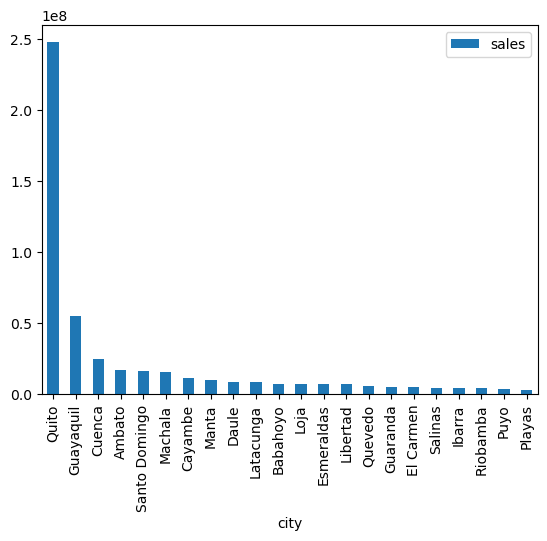

In [14]:
(retail_stores.groupby(["city"])
.agg({"sales":"sum"})
.sort_values(by="sales", ascending=False)
.plot.bar())

<Axes: xlabel='date'>

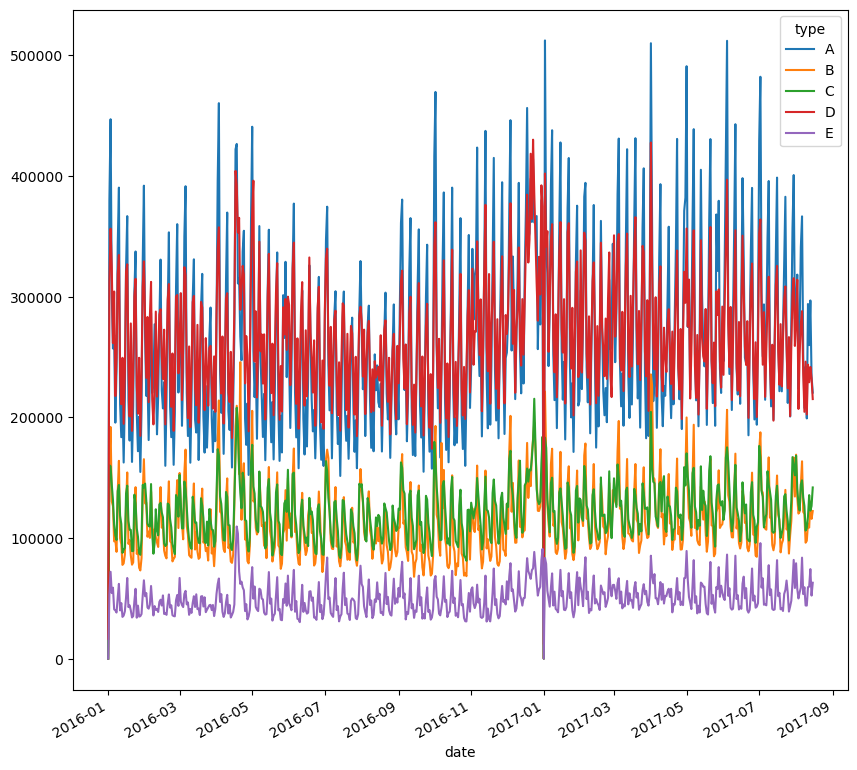

In [16]:
retail_stores.pivot_table(
    index=["date"],
    columns="type",
    values="sales",
    aggfunc="sum"
).plot(figsize=(10,10))

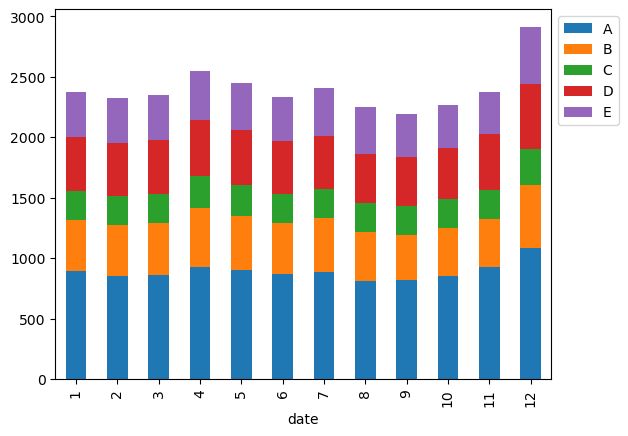

In [17]:
retail_stores.pivot_table(
    index="type",
    columns=retail_stores["date"].dt.month,
    values="sales",
    aggfunc="mean"
).T.plot.bar(stacked=True).legend(bbox_to_anchor=(1,1))